# Embedding

This short practical exercise allows you to experiment with embeddings to help you see how tokens are represented by vectors of numbers.

In [ ]:
# This next example uses `gensim`
# You can install gensim by uncommenting the final line here, and running the cell
# This assumes that you have `conda` installed
# Note that the `yes` part of this command automatically accepts the question(s) asked in the installation
# If you'd like to review these yourself, run the command `conda install gensim` or `pip install gensim` at the command line

!yes|conda install gensim

First, let's get the embedding model.

Note that the term "model" here (and in the code below) relates only to the embedding model and not to the full large language model. Embedding models can be trained at the same time as LLMs, but it's common to use to a fixed, existing embedding, which has been previously learned.

In [ ]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-100")

embedding = model["cat"]

print(embedding.shape)

In [ ]:
model["king"]

In [9]:
model.most_similar("king")

[('prince', 0.7682328820228577),
 ('queen', 0.7507690787315369),
 ('son', 0.7020888328552246),
 ('brother', 0.6985775232315063),
 ('monarch', 0.6977890729904175),
 ('throne', 0.6919989585876465),
 ('kingdom', 0.6811409592628479),
 ('father', 0.6802029013633728),
 ('emperor', 0.6712858080863953),
 ('ii', 0.6676074266433716)]

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

v1 = model["king"].reshape(1, -1)
v2 = model["queen"].reshape(1, -1)

similarity = cosine_similarity(v1, v2)[0, 0]

print(similarity)

0.7507691


In [11]:
model.most_similar(model["paris"]-model["france"]+model["germany"])

[('berlin', 0.8810449838638306),
 ('frankfurt', 0.7958397269248962),
 ('vienna', 0.7604520916938782),
 ('munich', 0.7508679628372192),
 ('germany', 0.7424821853637695),
 ('hamburg', 0.7172763347625732),
 ('paris', 0.7057966589927673),
 ('bonn', 0.6864470839500427),
 ('prague', 0.680591344833374),
 ('cologne', 0.6736196875572205)]

In [12]:
model["king"]-model["man"]+model["woman"]

array([-0.10231996, -0.81294006,  0.10211003,  0.985924  ,  0.34218282,
        1.09095   , -0.48912996, -0.05616698, -0.21029997, -1.02996   ,
       -0.86851   ,  0.36786997,  0.01960999,  0.59259   , -0.23190099,
       -1.016919  , -0.01218399, -1.17194   , -0.52329   ,  0.60645   ,
       -0.98537004, -1.001028  ,  0.48913902,  0.630072  ,  0.58224   ,
        0.15908998,  0.43685   , -1.25351   ,  0.97054   , -0.065529  ,
        0.733763  ,  0.44219002,  1.2091839 ,  0.19698   , -0.15948   ,
        0.34364003, -0.46222997,  0.33772   ,  0.14792705, -0.24959502,
       -0.77093005,  0.522717  , -0.1283    , -0.91881   , -0.01755001,
       -0.44041002, -0.52656496,  0.33734798,  0.60639   , -0.45067   ,
       -0.04158002,  0.08408299,  1.31456   ,  0.67737997, -0.24316001,
       -2.071     , -0.60648996,  0.19710997,  0.63567   ,  0.07819998,
        0.49161002,  0.08171999,  0.70855707,  0.201938  ,  0.5155501 ,
       -0.23025298, -0.40473002,  0.39212003, -0.5093    , -0.13

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

v1 = model["queen"].reshape(1, -1)
v2 = model["king"]-model["man"]+model["woman"].reshape(1, -1)

similarity = cosine_similarity(v1, v2)[0, 0]

print(similarity)

0.78344136


In [14]:
model.most_similar(model["king"]-model["man"]+model["woman"])

[('king', 0.8551837205886841),
 ('queen', 0.783441424369812),
 ('monarch', 0.6933802366256714),
 ('throne', 0.6833109855651855),
 ('daughter', 0.6809081435203552),
 ('prince', 0.6713141798973083),
 ('princess', 0.664408266544342),
 ('mother', 0.6579325795173645),
 ('elizabeth', 0.6563301086425781),
 ('father', 0.6392418742179871)]

In [15]:
model.most_similar(

    positive=["king", "woman"],

    negative=["man"]

)

[('queen', 0.7698540687561035),
 ('monarch', 0.6843381524085999),
 ('throne', 0.6755736470222473),
 ('daughter', 0.6594556570053101),
 ('princess', 0.6520534157752991),
 ('prince', 0.6517034769058228),
 ('elizabeth', 0.6464517712593079),
 ('mother', 0.631171703338623),
 ('emperor', 0.6106470823287964),
 ('wife', 0.6098655462265015)]

In [16]:
model.most_similar(model["king"]-model["queen"]+model["woman"])

[('man', 0.79038405418396),
 ('woman', 0.7741765379905701),
 ('father', 0.7262258529663086),
 ('son', 0.7059726119041443),
 ('boy', 0.6985020041465759),
 ('another', 0.6857765316963196),
 ('person', 0.6736670732498169),
 ('who', 0.6735799908638),
 ('brother', 0.6696273684501648),
 ('mother', 0.6615833640098572)]

In [17]:
model.most_similar(model["king"]-model["man"]+model["boy"])

[('king', 0.8525660634040833),
 ('queen', 0.6612487435340881),
 ('prince', 0.6361567974090576),
 ('son', 0.6191442012786865),
 ('brother', 0.5989434123039246),
 ('uncle', 0.5902641415596008),
 ('emperor', 0.578257143497467),
 ('throne', 0.5773313641548157),
 ('father', 0.5682175159454346),
 ('boy', 0.5664733648300171)]

In [18]:
model.most_similar("university")

[('college', 0.8294212818145752),
 ('harvard', 0.8156033754348755),
 ('yale', 0.8113803267478943),
 ('professor', 0.8103784918785095),
 ('graduate', 0.7993000745773315),
 ('faculty', 0.7793422341346741),
 ('princeton', 0.762718141078949),
 ('institute', 0.7604438662528992),
 ('school', 0.7548453211784363),
 ('stanford', 0.7424825429916382)]

In [19]:
model["cat"]

array([ 0.23088  ,  0.28283  ,  0.6318   , -0.59411  , -0.58599  ,
        0.63255  ,  0.24402  , -0.14108  ,  0.060815 , -0.7898   ,
       -0.29102  ,  0.14287  ,  0.72274  ,  0.20428  ,  0.1407   ,
        0.98757  ,  0.52533  ,  0.097456 ,  0.8822   ,  0.51221  ,
        0.40204  ,  0.21169  , -0.013109 , -0.71616  ,  0.55387  ,
        1.1452   , -0.88044  , -0.50216  , -0.22814  ,  0.023885 ,
        0.1072   ,  0.083739 ,  0.55015  ,  0.58479  ,  0.75816  ,
        0.45706  , -0.28001  ,  0.25225  ,  0.68965  , -0.60972  ,
        0.19578  ,  0.044209 , -0.31136  , -0.68826  , -0.22721  ,
        0.46185  , -0.77162  ,  0.10208  ,  0.55636  ,  0.067417 ,
       -0.57207  ,  0.23735  ,  0.4717   ,  0.82765  , -0.29263  ,
       -1.3422   , -0.099277 ,  0.28139  ,  0.41604  ,  0.10583  ,
        0.62203  ,  0.89496  , -0.23446  ,  0.51349  ,  0.99379  ,
        1.1846   , -0.16364  ,  0.20653  ,  0.73854  ,  0.24059  ,
       -0.96473  ,  0.13481  , -0.0072484,  0.33016  , -0.1236

In [20]:
import pandas as pd

In [21]:
words = model.index_to_key

In [22]:
words

['the',
 ',',
 '.',
 'of',
 'to',
 'and',
 'in',
 'a',
 '"',
 "'s",
 'for',
 '-',
 'that',
 'on',
 'is',
 'was',
 'said',
 'with',
 'he',
 'as',
 'it',
 'by',
 'at',
 '(',
 ')',
 'from',
 'his',
 "''",
 '``',
 'an',
 'be',
 'has',
 'are',
 'have',
 'but',
 'were',
 'not',
 'this',
 'who',
 'they',
 'had',
 'i',
 'which',
 'will',
 'their',
 ':',
 'or',
 'its',
 'one',
 'after',
 'new',
 'been',
 'also',
 'we',
 'would',
 'two',
 'more',
 "'",
 'first',
 'about',
 'up',
 'when',
 'year',
 'there',
 'all',
 '--',
 'out',
 'she',
 'other',
 'people',
 "n't",
 'her',
 'percent',
 'than',
 'over',
 'into',
 'last',
 'some',
 'government',
 'time',
 '$',
 'you',
 'years',
 'if',
 'no',
 'world',
 'can',
 'three',
 'do',
 ';',
 'president',
 'only',
 'state',
 'million',
 'could',
 'us',
 'most',
 '_',
 'against',
 'u.s.',
 'so',
 'them',
 'what',
 'him',
 'united',
 'during',
 'before',
 'may',
 'since',
 'many',
 'while',
 'where',
 'states',
 'because',
 'now',
 'city',
 'made',
 'like',
 

In [23]:
len(words)

400000

In [24]:
?model.most_similar

Signature:
model.most_similar(
    positive=None,
    negative=None,
    topn=10,
    clip_start=0,
    clip_end=None,
    restrict_vocab=None,
    indexer=None,
)
Docstring:
Find the top-N most similar keys.
Positive keys contribute positively towards the similarity, negative keys negatively.

This method computes cosine similarity between a simple mean of the projection
weight vectors of the given keys and the vectors for each key in the model.
The method corresponds to the `word-analogy` and `distance` scripts in the original
word2vec implementation.

Parameters
----------
positive : list of (str or int or ndarray) or list of ((str,float) or (int,float) or (ndarray,float)), optional
    List of keys that contribute positively. If tuple, second element specifies the weight (default `1.0`)
negative : list of (str or int or ndarray) or list of ((str,float) or (int,float) or (ndarray,float)), optional
    List of keys that contribute negatively. If tuple, second element specifies the we

In [25]:
model.most_similar(model["sushi"]-model["japan"]+model["germany"])

[('pastry', 0.5279677510261536),
 ('sushi', 0.5256781578063965),
 ('ducasse', 0.5234885215759277),
 ('gourmet', 0.5166001319885254),
 ('hamburger', 0.5080069303512573),
 ('sausage', 0.5010420680046082),
 ('dessert', 0.4999590814113617),
 ('cheese', 0.4974646270275116),
 ('fries', 0.4795070290565491),
 ('cheesecake', 0.47740674018859863)]

In [26]:
model.most_similar(model["bratwurst"])

[('bratwurst', 1.0),
 ('sauerkraut', 0.6685113310813904),
 ('sausages', 0.6250906586647034),
 ('kielbasa', 0.6003972887992859),
 ('sausage', 0.5902236104011536),
 ('choucroute', 0.5236543416976929),
 ('oktoberfest', 0.5162939429283142),
 ('frankfurters', 0.5039279460906982),
 ('currywurst', 0.4967309236526489),
 ('merguez', 0.4956762492656708)]

In [27]:
model.most_similar("bratwurst")

[('sauerkraut', 0.6685113310813904),
 ('sausages', 0.6250906586647034),
 ('kielbasa', 0.6003972887992859),
 ('sausage', 0.5902236104011536),
 ('choucroute', 0.5236543416976929),
 ('oktoberfest', 0.5162939429283142),
 ('frankfurters', 0.5039279460906982),
 ('currywurst', 0.4967309236526489),
 ('merguez', 0.49567627906799316),
 ('ravioli', 0.49563759565353394)]

In [28]:
model.most_similar(positive="hot")

[('cool', 0.771088719367981),
 ('cold', 0.7251606583595276),
 ('warm', 0.6978106498718262),
 ('heat', 0.6798572540283203),
 ('soft', 0.6601648926734924),
 ('dry', 0.656905472278595),
 ('hottest', 0.6359643936157227),
 ('ice', 0.6257197260856628),
 ('mix', 0.6253519058227539),
 ('summer', 0.618662416934967)]

In [29]:
model.most_similar(positive="desert", negative="hot")

[('mojave', 0.5249858498573303),
 ('sonoran', 0.506641685962677),
 ('cholistan', 0.5048995614051819),
 ('namib', 0.5004015564918518),
 ('chihuahuan', 0.49228018522262573),
 ('anza-borrego', 0.4881615936756134),
 ('negev', 0.47294533252716064),
 ('judean', 0.46352434158325195),
 ('taklamakan', 0.4539128541946411),
 ('tabernas', 0.4524002969264984)]

In [30]:
model.most_similar(positive=["edinburgh","university"])

[('cambridge', 0.7644388675689697),
 ('oxford', 0.7513911128044128),
 ('glasgow', 0.7460184693336487),
 ('college', 0.7333678603172302),
 ('academy', 0.6862157583236694),
 ('harvard', 0.682809591293335),
 ('professor', 0.6792548298835754),
 ('yale', 0.6773259043693542),
 ('melbourne', 0.6729219555854797),
 ('princeton', 0.6684866547584534)]

In [31]:
model.most_similar("haggis")

[('moresco', 0.5662769079208374),
 ('greengrass', 0.5598293542861938),
 ('verhoeven', 0.5274224281311035),
 ('oakenfold', 0.5029656291007996),
 ('chayefsky', 0.49769753217697144),
 ('gaghan', 0.49258148670196533),
 ('reubens', 0.488735556602478),
 ('resnais', 0.4843463599681854),
 ('darabont', 0.48265331983566284),
 ('w.s.', 0.46595191955566406)]

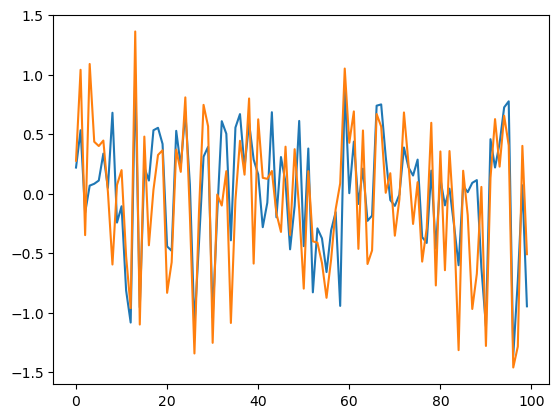

In [32]:
import matplotlib.pyplot as plt 
plt.plot(model["viola"])
plt.plot(model["violin"])